## 머신러닝
### 1. 데이터를 탐색하고 탐색 결과를 제시하시오.
### 2. 결측치를 탐색하고 대체 방법 및 근거를 제시하시오.
### 3. 데이터의 질을 향상시킬 수 있는 방법을 제안하시오.
### 4. 데이터 불균형을 시각화하여 식별하고 불균형 판단근거를 작성하시오.
### 5. 오버 샘플링 기법을 설명하고, 비교한 뒤 2개 기법을 선정하고 근거를 제시하시오.
### 6. 기법을 선정한 이유를 작성하고, 원데이터를 포함해 3개의 데이터 세트를 구성하시오
### 7. 오버 샘플링 데이터와 원데이터를 사용해 정확도 측면 모델 하나와 속도 측면의 모델 하나를 선정하고, 그 이유를 설명하시오.
### 8. 원 데이터와 오버 샘플링 데이터를 가지고 각각 분류한 결과를 바탕으로, 오버샘플링이 성능에 미친 영향에 대해 작성하시오.

## 통계분석
### 1. 공장에서 시제품의 농도(%)가 60이라고 주장하며, 품질관리팀에서 10개의 샘플을 뽑았다. 유의수준 5%에서 다음을 검정하시오
### 데이터 : (시제품 샘플 농도) : 52,50,62,75,26,45,62,35,57,14
### 1-1) 연구가설, 귀무가설을 작성하시오.
### 1-2) 유효한 샘플의 수를 계산하시오.
### 1-3) 검정통계량을 구하고 연구가설 채택 여부를 작성하시오.

### 2. 코로나 시계열 데이터로 다음을 수행하시오.
### 데이터 : 지역별 코로나 확진자 수 시계열 데이터
### 2-1) ACF 사용해서 distance를 계산하시오.
### 2-2) 계층적 군집분석을 위해 덴드로그램을 작성하시오.


### 3. 사회과학, 자연과학, 공학 세 개 학과의 평점조사표를 보고 학과와 성적이 관계 있는지 검정하시오.
### 3-1) 연구가설, 귀무가설을 작성하시오
### 3-2) 학과와 성적이 독립일 때 기대값을 구하시오.
### 3-3) 검정 통계량을 구하고 연구가설 채택 여부를 작성하시오.

## 머신러닝

### 1. 데이터를 탐색하고 탐색 결과를 제시하시오.

In [117]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/hotel_bookings.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   is_canceled                     20000 non-null  int64  
 1   deposit_type                    20000 non-null  object 
 2   lead_time                       19995 non-null  float64
 3   stays_in_weekend_nights         20000 non-null  int64  
 4   stays_in_week_nights            20000 non-null  int64  
 5   is_repeated_guest               19642 non-null  float64
 6   previous_cancellations          20000 non-null  int64  
 7   previous_bookings_not_canceled  20000 non-null  int64  
 8   booking_changes                 20000 non-null  int64  
 9   days_in_waiting_list            20000 non-null  int64  
 10  adr                             18937 non-null  float64
dtypes: float64(3), int64(7), object(1)
memory usage: 1.7+ MB


In [ ]:
### 1-1) 데이터 타입설명
'''
is_canceled                     int64  
stays_in_weekend_nights         int64  
stays_in_week_nights            int64  
previous_cancellations          int64  
previous_bookings_not_canceled  int64  
booking_changes                 int64  
days_in_waiting_list            int64  
adr                             float64
lead_time                       float64
is_repeated_guest               float64
deposit_type                    object  > 인코딩을 통하여 변화해줄 필요가 있어보인다.
'''

<BarContainer object of 2 artists>

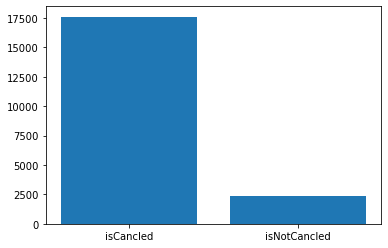

In [12]:
## 1-2) 종속변수 분포 설명
df['is_canceled'].value_counts().index
df['is_canceled'].value_counts().values
import matplotlib.pyplot as plt
plt.bar(['isCancled', 'isNotCancled'],df['is_canceled'].value_counts().values )

<AxesSubplot:>

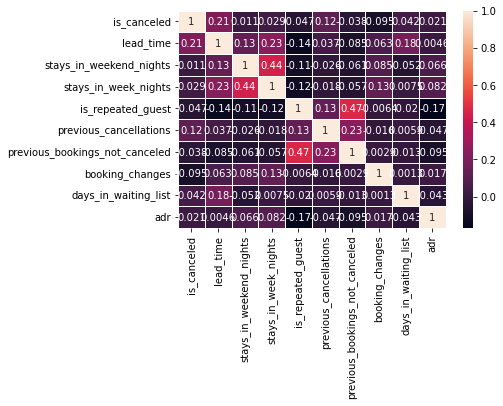

In [20]:
## 1-3) 독립변수 간 상관관계 > X
## 1-4) 독립변수와 종속변수의 상관관계 > X
df_corr = df.corr(method='pearson')
import seaborn as sns
sns.heatmap(df_corr, xticklabels=df_corr.columns, yticklabels=df_corr.columns, annot = True, linewidth = 1)

<BarContainer object of 2 artists>

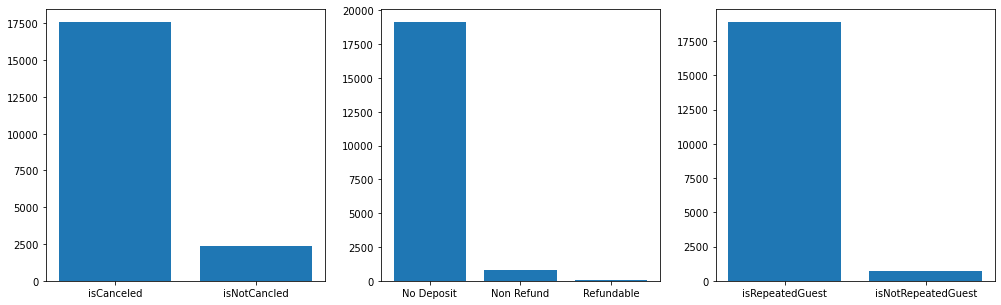

In [41]:
## 1-5) 범주형 변수 설명
fig, axs = plt.subplots(1,3, figsize = (17,5))
axs[0].bar(['isCanceled', 'isNotCancled'], df['is_canceled'].value_counts().values )
# deposit_type 별 평균 adr
axs[1].bar(df['deposit_type'].value_counts().index, df['deposit_type'].value_counts().values ) 
axs[2].bar(['isRepeatedGuest', 'isNotRepeatedGuest'], df['is_repeated_guest'].value_counts().values )

AxesSubplot(0.125,0.125;0.775x0.755)
is_canceled                          0
deposit_type                         0
lead_time                            5
stays_in_weekend_nights              0
stays_in_week_nights                 0
is_repeated_guest                  358
previous_cancellations               0
previous_bookings_not_canceled       0
booking_changes                      0
days_in_waiting_list                 0
adr                               1063
dtype: int64
lead_time 결측치 비율 :  0.03 %
is_repeated_guest 결측치 비율 :  1.79 %
adr 결측치 비율 :  5.34 %


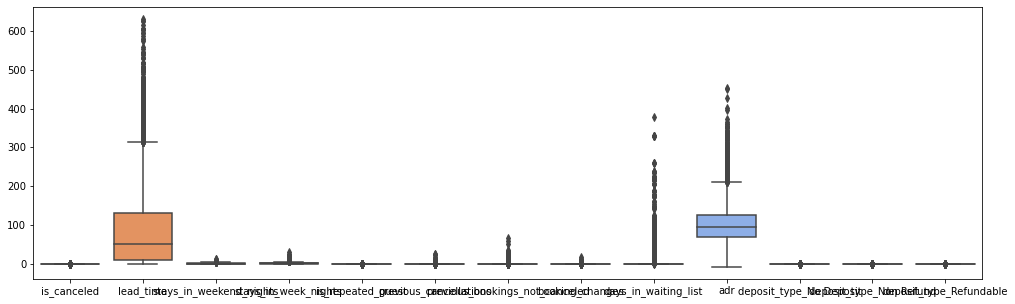

In [61]:
## 1-6) 이상치 > 연속형
df_t = pd.get_dummies(df, columns = ['deposit_type'])
plt.figure(figsize = (17,5))
print(sns.boxplot(data = df_t))

## 1-7) 결측치 > lead_time, is_repeated_guest, adr, 변수와 비율과 분포에 따라 각각 다른 결측치 대체 방식
print(df.isnull().sum())
print('lead_time 결측치 비율 : ', (round(5/len(df) * 100,2)), '%') # 1% 미만이므로 결측치 있는 행 삭제
print('is_repeated_guest 결측치 비율 : ', (round(358/len(df) * 100,2)), '%') # 최빈값 대체
print('adr 결측치 비율 : ', (round(1068/len(df) * 100,2)), '%') # deposit_type별 평균 adr로 대체

### 2. 결측치를 탐색하고 대체 방법 및 근거를 제시하시오.

In [118]:
print(df.isnull().sum())

print('lead_time 결측치 비율 : ', (round(5/len(df) * 100,2)), '%') 
print('is_repeated_guest 결측치 비율 : ', (round(358/len(df) * 100,2)), '%') 
print('adr 결측치 비율 : ', (round(1068/len(df) * 100,2)), '%') 

df.dropna(subset = ['lead_time'], axis = 0, inplace = True) # 1% 미만이므로 결측치 있는 행 삭제
df['is_repeated_guest'].fillna(0, inplace = True) # 최빈값 대체
fill_mean_func = lambda g : g.fillna(g.mean()) # deposit_type별 평균 adr로 대체
df = df.groupby('deposit_type').apply(fill_mean_func)

print(df.isnull().sum())

is_canceled                          0
deposit_type                         0
lead_time                            5
stays_in_weekend_nights              0
stays_in_week_nights                 0
is_repeated_guest                  358
previous_cancellations               0
previous_bookings_not_canceled       0
booking_changes                      0
days_in_waiting_list                 0
adr                               1063
dtype: int64
lead_time 결측치 비율 :  0.03 %
is_repeated_guest 결측치 비율 :  1.79 %
adr 결측치 비율 :  5.34 %
is_canceled                       0
deposit_type                      0
lead_time                         0
stays_in_weekend_nights           0
stays_in_week_nights              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
days_in_waiting_list              0
adr                               0
dtype: int64


C:\Users\KDB\AppData\Local\Temp\ipykernel_62436\1421849429.py:9: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  fill_mean_func = lambda g : g.fillna(g.mean()) # deposit_type별 평균 adr로 대체


### 3. 데이터의 질을 향상시킬 수 있는 방법을 제안하시오.
#### IQR 방식으로 lead_time 변수의 이상치를 보정해주어, 극단적인 값으 제거함으로써 모델에 특정 값이 영향을 주는 경우를 방지한다.
#### 또는 is_repeated_guest 변수에서 [1]에 해당하는 데이터를 더 수집해 해당 변수의 불균형을 해소한다.

### 4. 데이터 불균형을 시각화하여 식별하고 불균형 판단근거를 작성하시오.

isCanceled :  88.0 %
isNotCancled :  12.0 %
--------------------------
noDeposit :  95.7 %
nonRefund :  4.2 %
refundable :  0.1 %
--------------------------
isRepeatedGuest :  94.5 %
isNotRepeatedGuest :  3.6999999999999997 %


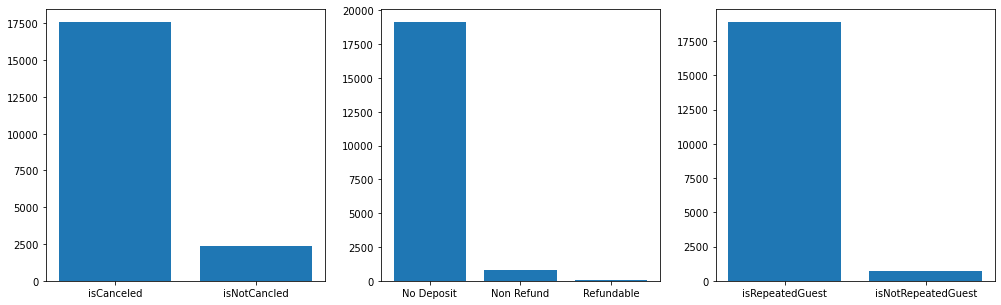

In [86]:
fig, axs = plt.subplots(1,3, figsize = (17,5))
axs[0].bar(['isCanceled', 'isNotCancled'], df['is_canceled'].value_counts().values )
# > deposit_type 별 평균 adr
axs[1].bar(df['deposit_type'].value_counts().index, df['deposit_type'].value_counts().values ) 
axs[2].bar(['isRepeatedGuest', 'isNotRepeatedGuest'], df['is_repeated_guest'].value_counts().values )


print('isCanceled : ', round(df['is_canceled'].value_counts().values[0]/len(df['is_canceled']),3) * 100, '%')
print('isNotCancled : ', round(df['is_canceled'].value_counts().values[1]/len(df['is_canceled']),3) * 100, '%')
print("--------------------------")

print('noDeposit : ', round(df['deposit_type'].value_counts().values[0]/len(df['deposit_type']),3) * 100, '%')
print('nonRefund : ', round(df['deposit_type'].value_counts().values[1]/len(df['deposit_type']),3) * 100, '%')
print('refundable : ', round(df['deposit_type'].value_counts().values[2]/len(df['deposit_type']),3) * 100, '%')
print("--------------------------")

print('isRepeatedGuest : ', round(df['is_repeated_guest'].value_counts().values[0]
                                  /len(df['is_repeated_guest']),3) * 100, '%')
print('isNotRepeatedGuest : ', round(df['is_repeated_guest'].value_counts().values[1]
                                     /len(df['is_repeated_guest']),3) * 100, '%')


### 5. 오버 샘플링 기법을 설명하고, 비교한 뒤 2개 기법을 선정하고 근거를 제시하시오.
#### 업 샘플링은 소수 레이블을 가진 데이터세트를 다수 레이블을 가진 데이터세트의 수 만큼 증식시켜 학습에 충분한 데이터를 확보하는 기법이다.
#### 일반적으로 불균형한 데이터를 처리하는 방식으로 업 샘플링을 사용하는데, 이는 언더 샘플링의 경우 데이터 손실의 문제로 예측성능이 저하되는 단점이 있기 때문이다.

#### 대표적으로 랜덤오버샘플링과 KNN을 이용한 SMOTE 기법이 있다.
#### 랜덤오버샘플링은 소수 클래스의 정보를 복제하여 다수 클래스의 크기에 맞추는 기법이며, 이는 과적합의 우려가 있다.
#### SMOTE는 KNN을 이용하여 최근접 이웃의 거리 계산을 통해 K개의 중간 지점의 데이터를 생성한다.
#### 과적합을 막을 수 있으나, 새로운 데이터나 작은 데이터셋에서는 사용하기가 어렵다.

### 6. 기법을 선정한 이유를 작성하고, 원데이터를 포함해 3개의 데이터 세트를 구성하시오
#### 오버 샘플링 방식으로 Random Oversampling과 SMOTE를 선택한다. 
#### 그 이유는 Random Oversampling은 간단한 방식으로 데이터 불균형 문제를 해결할 수 있기 때문이다.
#### SMOTE는 데이터를 생성할 때 과적합 문제를 방지할 수 있다는 점에서 선택했다.

In [140]:
df = pd.get_dummies(df)
df

from imblearn.over_sampling import RandomOverSampler, SMOTE
import time
X = df.drop(['is_canceled'], axis = 1)
y = df['is_canceled']

# RandomOverSampler
start = time.time()
ros = RandomOverSampler(random_state = 2022)
X_r_r, y_r_r = ros.fit_resample(X, y)
end = time.time()
print('RandomOverSampling time : ', end - start)

# SMOTE
start = time.time()
smote = SMOTE(random_state = 2022)
X_s_r, y_s_r = smote.fit_resample(X,y)
end = time.time()
print('SMOTE time : ', end - start)

RandomOverSampling time :  0.025992155075073242
SMOTE time :  0.04600834846496582


### 7. 오버 샘플링 데이터와 원데이터를 사용해 정확도 측면 모델 하나와 속도 측면의 모델 하나를 선정하고, 그 이유를 설명하시오.

In [149]:
# 원본 > 속도, 이는 원본 데이터가 오버 샘플링 데이터들에 비해 사이즈가 작기때문
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify =                                                    y
                                                    , test_size = 0.2, random_state = 2022)

start = time.time()
rfc = RandomForestClassifier(n_estimators=100, min_samples_split = 10)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
end = time.time()

print('정확도 : ', accuracy_score(y_test, y_pred))
print('속도 : ', end-start)
print(classification_report(y_test, y_pred))

정확도 :  0.9287321830457614
속도 :  1.4857821464538574
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3519
           1       0.99      0.41      0.58       480

    accuracy                           0.93      3999
   macro avg       0.96      0.70      0.77      3999
weighted avg       0.93      0.93      0.92      3999



In [151]:
# RandomOverSampler > 정확도, 원본은 제외하고 오버샘플링을 감안한다면 속도 측면에서도 가장 빠른 모델.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

X_train, X_test, y_train, y_test = train_test_split(X_r_r, y_r_r, stratify = y_r_r
                                                    , test_size = 0.2, random_state = 2022)

start = time.time()
rfc = RandomForestClassifier(n_estimators=100, min_samples_split = 10)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
end = time.time()

print('정확도 : ', accuracy_score(y_test, y_pred))
print('속도 : ', end-start)
print(classification_report(y_test, y_pred))

정확도 :  0.9541062801932367
속도 :  2.5301401615142822
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      3519
           1       0.94      0.97      0.95      3519

    accuracy                           0.95      7038
   macro avg       0.95      0.95      0.95      7038
weighted avg       0.95      0.95      0.95      7038



In [150]:
# SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

X_train, X_test, y_train, y_test = train_test_split(X_s_r, y_s_r, stratify = y_s_r
                                                    , test_size = 0.2, random_state = 2022)

start = time.time()
rfc = RandomForestClassifier(n_estimators=100, min_samples_split = 10)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
end = time.time()

print('정확도 : ', accuracy_score(y_test, y_pred))
print('속도 : ', end-start)
print(classification_report(y_test, y_pred))

정확도 :  0.8917306052855924
속도 :  2.893950939178467
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      3519
           1       0.92      0.86      0.89      3519

    accuracy                           0.89      7038
   macro avg       0.89      0.89      0.89      7038
weighted avg       0.89      0.89      0.89      7038



### 8. 원 데이터와 오버 샘플링 데이터를 가지고 각각 분류한 결과를 바탕으로, 오버샘플링이 성능에 미친 영향에 대해 작성하시오.
#### 원본데이터 랜덤포레스트 분류 > train score
#### 오버샘플링 랜덤포레스트 분류 > train score
#### 하지만 test 데이터로 모델의 최종 성능을 비교해보면 오버 샘플링 분석 정확도에 긍정적인 영향을 주었다는 것을 알 수 있다.
#### 특히, 오버 샘플링은 데이터의 불균형으로 인한 과적합을 방지하고, 예측 모델의 일반화를 가능하게 했다는 점에서 영향을 주었다. 
#### 원본데이터 test 데이터의 f1_score 내 Macro Average, Weighted Average > 각각 Train 데이터와 비교 후 과적합발생
#### 오버샘플링 데이터  test 데이터의 f1_score 내 Macro Average, Weighted Average > 각각 Train 데이터와 비교 후 과적합발생 X
#### 데이터의 불균형 문제를 전처리 과정에서 극복했기 때문이다. 따라서 오버 샘플링 처리를 한 예측모델은 일반화가 가능하다고 판단되므로
#### 실제 분석환경에서 사용할 수 있다.

## 통계분석

### 1. 공장에서 시제품의 농도(%)가 60이라고 주장하며, 품질관리팀에서 10개의 샘플을 뽑았다. 유의수준 5%에서 다음을 검정하시오
### 데이터 : (시제품 샘플 농도) : 52,50,62,75,26,45,62,35,57,14
### 1-1) 연구가설, 귀무가설을 작성하시오.
#### H0 : 시제품의 농도는 60%이다. H1 : 시제품의 농도는 60%가 아니다.

### 1-2) 유효한 샘플의 수를 계산하시오.

In [156]:
x = [52,50,62,75,26,45,62,35,57,14]
import numpy as np
from scipy.stats import t

moe = 5 # 오차한계
std = np.std(x) # 표준편차
print('표준편차 : ', std)
print('유의수준 : 0.05, 자유도 : 9의 t값 : ',  t.ppf(q = 0.05, df = 9))
(t.ppf(q = 0.05, df = 9)*std / 5) ** 2 # ppf 누적분포함수의 역함수

표준편차 :  17.434448657758008
유의수준 : 0.05, 자유도 : 9의 t값 :  -1.8331129326536337


40.85590828532381

#### 유효한 샘플의 수는 약 41개 이상이다.
#### 유효한 샘플의 수는 최소 표본 크기를 계산하여 설정할 수 있다.
#### 최소 표본크기의 계산은 허용오차식을 바탕으로 한다.
#### 허용할 수 있는 오차한계와 신뢰수준이 주어졌을 때 샘플로부터 추정한 표준편차를 사용해 표본의 크기를 구할 수 있다.
#### 오차한계를 5, 신뢰수준을 0.05로 설정한 뒤 샘플의 표준편차를 구한다.
#### 허용오차식에 오차한계 5, 신뢰수준 0.05, 샘플의 표준편차를 대입한다.
#### 결과가 40.85이므로, 유효한 샘플 수는 41 이상이다.

### 1-3) 검정통계량을 구하고 연구가설 채택 여부를 작성하시오.

In [16]:
from scipy import stats
import pandas as pd
stats.wilcoxon(pd.Series(x)-60)

WilcoxonResult(statistic=9.5, pvalue=0.064453125)

#### Wilcoxon의 부호검정을 검정방법으로 선택한다. 이 검정방식은 모집단이 정규성을 만족하지 못할 때 사용하는 검정이다.
#### 비교대상들 사이의 차이를 부호와 크기에 대한 정보로 바꾸어 이를 토대로 분포를 비교하는 방식이다.
#### 검정 결과 p-value가 0.06이므로 0.05보다 크다. 따라서 귀무가설을 채택한다. 즉 시제품의 농도는 60%라고 판단할 수 있다.

### 2. 코로나 시계열 데이터로 다음을 수행하시오.
### 데이터 : 지역별 코로나 확진자 수 시계열 데이터

### 2-1) ACF 사용해서 distance를 계산하시오.

In [177]:
import pandas as pd
df = pd.read_csv('data/서울특별시 코로나19.csv')
covid1 = df.drop(['날짜'], axis = 1)
covid1

,종로구,중구,용산구,성동구,광진구,동대문구,중랑구,성북구,강북구,도봉구,...,강서구,구로구,금천구,영등포구,동작구,관악구,서초구,강남구,송파구,강동구
0,37261,33753,55376,81018,96008,95433,103288,116862,75118,82254,...,148359,109973,63687,110293,106238,132305,104368,136200,176765,121926
1,36216,32835,53872,79030,93474,92993,100255,113609,72934,79677,...,143573,106162,61840,106171,102955,127626,100529,132333,172292,118842
2,35276,31878,52391,76802,91030,90277,97419,110583,70754,77878,...,139633,103573,59946,104109,100665,124805,98869,128813,167386,115846
3,34879,31577,51652,76108,89876,89302,96359,109500,70003,76542,...,137908,102610,59393,102916,99426,123374,96873,126296,165373,113549
4,34061,30903,50720,74178,87770,87345,93690,106437,68329,75119,...,134285,99938,57925,100349,96989,120413,95124,123992,161650,110649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
783,3,0,0,0,0,0,1,2,0,0,...,1,0,0,0,0,0,0,0,1,0


### 2-2) 계층적 군집분석을 위해 덴드로그램을 작성하시오.

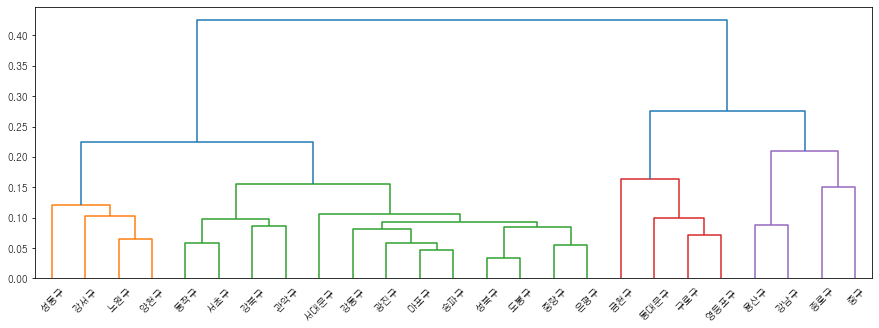

array([[7.00000000e+00, 9.00000000e+00, 3.34534060e-02, 2.00000000e+00],
       [1.30000000e+01, 2.30000000e+01, 4.72331662e-02, 2.00000000e+00],
       [6.00000000e+00, 1.10000000e+01, 5.51661512e-02, 2.00000000e+00],
       [4.00000000e+00, 2.60000000e+01, 5.83714620e-02, 3.00000000e+00],
       [1.90000000e+01, 2.10000000e+01, 5.84773571e-02, 2.00000000e+00],
       [1.00000000e+01, 1.40000000e+01, 6.56812352e-02, 2.00000000e+00],
       [1.60000000e+01, 1.80000000e+01, 7.07502603e-02, 2.00000000e+00],
       [2.40000000e+01, 2.80000000e+01, 8.10869822e-02, 4.00000000e+00],
       [2.50000000e+01, 2.70000000e+01, 8.41483022e-02, 4.00000000e+00],
       [8.00000000e+00, 2.00000000e+01, 8.61853383e-02, 2.00000000e+00],
       [2.00000000e+00, 2.20000000e+01, 8.86165184e-02, 2.00000000e+00],
       [3.20000000e+01, 3.30000000e+01, 9.21603199e-02, 8.00000000e+00],
       [2.90000000e+01, 3.40000000e+01, 9.76566999e-02, 4.00000000e+00],
       [5.00000000e+00, 3.10000000e+01, 1.00305512e

In [202]:
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

from matplotlib import font_manager, rc

font_path = "C:/Windows/Fonts/NGULIM.TTF"
font = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family = font)

def acf(x, n_lags):
    return sm.tsa.stattools.acf(x, nlags = n_lags)

# Max ACF lags
n_lags = 785
lag_arr = np.repeat(n_lags, covid1.shape[1]) # n_lags 값을 covid.shape[1] 크기 만큼 반복.
#covid1.transpose().to_numpy() # index은 열 기준 ex) index 0 > 종로구
acf_list = list(map(acf,covid1.transpose().to_numpy(), lag_arr )) # 열 기준 리스트화
acf_df = pd.DataFrame(acf_list).transpose()
acf_df.columns = covid1.columns

# 계층적 군집분석의 입력형태를 맞추기 위해 acf_df를 transpose
acf_df = acf_df.T

# 덴드로그램
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from matplotlib import pyplot as plt

plt.figure(figsize = (15,5))
label = acf_df.index
dend1 = linkage(acf_df, method = 'average')
cutoff = 0.5 * max(dend1[:,2]) # 세번째 열은 클래스 사이의 거리 > 최대값의 50%로 설정
dend_res1 = dendrogram(dend1,
                    color_threshold = cutoff,
                    labels = label)
plt.show()
dend1

### 3. 사회과학, 자연과학, 공학 세 개 학과의 평점조사표를 보고 학과와 성적이 관계 있는지 검정하시오.
### 3-1) 연구가설, 귀무가설을 작성하시오
#### H0 : 성적과 학점 간에는 관련성이 없다. H1 : 성적과 학점 간에는 관련성이 있다.

In [31]:
사회 = [16,30,12]
자연과학 = [12,20,3]
공학 = [18,13,14]
table = pd.DataFrame({'사회과학' : 사회, '자연과학' : 자연과학,'공학' : 공학}
                     , index = ['3.5~4.5', '2.5~3.5', '1.5~2.5'])
table

,사회과학,자연과학,공학
3.5~4.5,16,12,18
2.5~3.5,30,20,13
1.5~2.5,12,3,14


### 3-2) 학과와 성적이 독립일 때 기대값을 구하시오.

In [44]:
from scipy import stats
#help(stats.chi2_contingency(observed = table))
table_expected = stats.chi2_contingency(observed = table)
table_expected = pd.DataFrame(table_expected[3], columns = ['사회','자연과학','공학']
                              , index = ['3.5~4.5', '2.5~3.5', '1.5~2.5'])
table_expected

,사회,자연과학,공학
3.5~4.5,19.333333,11.666667,15.000000
2.5~3.5,26.478261,15.978261,20.543478
1.5~2.5,12.188406,7.355072,9.456522


#### 9개의 기댓값은 pd.DataFrame을 통해 바로 위와 같이 계산했다.

### 3-3) 검정 통계량을 구하고 연구가설 채택 여부를 작성하시오.

In [49]:
table_expected = stats.chi2_contingency(observed = table)
print('검정통계량 : ' , table_expected[0])
print('유의확률 :  ' , table_expected[1])

검정통계량 :  10.199441509990177
유의확률 :   0.03719883770303157


#### chi-square 값은 10.199이고 p-value는 0.03이기 때문에 유의수준 0.05보다 작기 때문에 대립가설을 채택한다.
#### 즉, 성적과 학과 간에는 관련성이 있다.

In [62]:
# 기하평균 : 연 매출이 3000,4000,5000 > 연 평균 몇 배증가?
import numpy as np
a = (np.sqrt(((4000-3000)/3000) * ((5000-4000)/4000)))
print(a)
# 조화평균 : 갈 때 4km, 올 때 5km > 왕복평균속도는?
(2*4*5)/(4+5)

0.28867513459481287


4.444444444444445